# Project Name - Retail Store Analytics

### Import Libraries

In [103]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import os

## CONFIGURATION

In [138]:
FILE_PATH = "retail_store_analytics_complete_dataset.csv"
OUTPUT_DIR = "retail_analytics_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")

df = pd.read_csv("retail_store_analytics_complete_dataset.csv")
print(df)

     Transaction ID        Date Store ID         Store Name          City  \
0           T004163  2024-01-01    ST001  Main Market Store      Pilibhit   
1           T001138  2024-01-01    ST002  City Center Store      Bareilly   
2           T003052  2024-01-01    ST002  City Center Store      Bareilly   
3           T000980  2024-01-01    ST003      Highway Store  Shahjahanpur   
4           T000756  2024-01-01    ST004         Mall Store          Agra   
...             ...         ...      ...                ...           ...   
4995        T002446  2025-12-31    ST001  Main Market Store      Pilibhit   
4996        T003504  2025-12-31    ST001  Main Market Store      Pilibhit   
4997        T004302  2025-12-31    ST001  Main Market Store      Pilibhit   
4998        T001668  2025-12-31    ST004         Mall Store          Agra   
4999        T002670  2025-12-31    ST004         Mall Store          Agra   

              State Customer ID  Gender  Age Product ID  ... Stock After Sa

## 1. LOAD AND PREPARE DATA

In [3]:
# Convert date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [4]:
# Remove duplicate records
df = df.drop_duplicates()

In [5]:
# Dataset Shape 
print(df.shape) 

(5000, 35)


In [6]:
# First 5 Records
print(df.head(5)) 

  Transaction ID       Date Store ID         Store Name          City  \
0        T004163 2024-01-01    ST001  Main Market Store      Pilibhit   
1        T001138 2024-01-01    ST002  City Center Store      Bareilly   
2        T003052 2024-01-01    ST002  City Center Store      Bareilly   
3        T000980 2024-01-01    ST003      Highway Store  Shahjahanpur   
4        T000756 2024-01-01    ST004         Mall Store          Agra   

           State Customer ID  Gender  Age Product ID  ... Stock After Sale  \
0  Uttar Pradesh       C0650  Female   26       P002  ...              187   
1  Uttar Pradesh       C0341  Female   23       P012  ...              199   
2  Uttar Pradesh       C0983    Male   36       P017  ...              331   
3  Uttar Pradesh       C0973  Female   40       P011  ...              294   
4  Uttar Pradesh       C0462  Female   36       P004  ...              323   

  Reorder Level  Stock Status  Payment Method  Year  Month  Month Name  \
0            40   

In [7]:
# Column Names
print(df.columns.tolist())

['Transaction ID', 'Date', 'Store ID', 'Store Name', 'City', 'State', 'Customer ID', 'Gender', 'Age', 'Product ID', 'Product Name', 'Product Category', 'Quantity', 'Cost Price', 'Price per Unit', 'Discount %', 'Gross Sales', 'Discount Amount', 'Total Amount', 'Total Cost', 'Profit', 'Profit Margin %', 'Opening Stock', 'Purchased Stock', 'Stock Before Sale', 'Stock After Sale', 'Reorder Level', 'Stock Status', 'Payment Method', 'Year', 'Month', 'Month Name', 'Quarter', 'Day Name', 'Season']


In [8]:
# Missing Values
print(df.isnull().sum())

Transaction ID       0
Date                 0
Store ID             0
Store Name           0
City                 0
State                0
Customer ID          0
Gender               0
Age                  0
Product ID           0
Product Name         0
Product Category     0
Quantity             0
Cost Price           0
Price per Unit       0
Discount %           0
Gross Sales          0
Discount Amount      0
Total Amount         0
Total Cost           0
Profit               0
Profit Margin %      0
Opening Stock        0
Purchased Stock      0
Stock Before Sale    0
Stock After Sale     0
Reorder Level        0
Stock Status         0
Payment Method       0
Year                 0
Month                0
Month Name           0
Quarter              0
Day Name             0
Season               0
dtype: int64


In [9]:
# Data Types
print(df.dtypes)

Transaction ID               object
Date                 datetime64[ns]
Store ID                     object
Store Name                   object
City                         object
State                        object
Customer ID                  object
Gender                       object
Age                           int64
Product ID                   object
Product Name                 object
Product Category             object
Quantity                      int64
Cost Price                  float64
Price per Unit              float64
Discount %                    int64
Gross Sales                 float64
Discount Amount             float64
Total Amount                float64
Total Cost                  float64
Profit                      float64
Profit Margin %             float64
Opening Stock                 int64
Purchased Stock               int64
Stock Before Sale             int64
Stock After Sale              int64
Reorder Level                 int64
Stock Status                

In [13]:
# GENERAL KPI ANALYSIS
total_sales = df["Total Amount"].sum() 
total_profit = df["Profit"].sum() 
total_quantity = df["Quantity"].sum() 
total_transactions = df["Transaction ID"].nunique() 
total_customers = df["Customer ID"].nunique() 
total_products = df["Product ID"].nunique() 
total_stores = df["Store ID"].nunique() 
total_discount = df["Discount Amount"].sum() 

average_order_value = total_sales / total_transactions 
overall_profit_margin = (total_profit / total_sales) * 100 

print("\n" + "=" * 30) 
print("GENERAL BUSINESS KPIs") 
print("=" * 30) 
print(f"Total Sales : ₹{total_sales:,.2f}") 
print(f"Total Profit : ₹{total_profit:,.2f}") 
print(f"Total Quantity : {total_quantity:,}") 
print(f"Transactions : {total_transactions:,}") 
print(f"Customers : {total_customers:,}") 
print(f"Products : {total_products:,}") 
print(f"Stores : {total_stores:,}") 
print(f"Discount Given : ₹{total_discount:,.2f}") 
print(f"Average Order : ₹{average_order_value:,.2f}") 
print(f"Profit Margin : {overall_profit_margin:.2f}%")


GENERAL BUSINESS KPIs
Total Sales : ₹13,329,368.50
Total Profit : ₹4,181,423.50
Total Quantity : 10,866
Transactions : 5,000
Customers : 1,185
Products : 20
Stores : 5
Discount Given : ₹1,064,801.50
Average Order : ₹2,665.87
Profit Margin : 31.37%


## MODULE 1 — STORE PERFORMANCE

In [22]:
store_performance = ( df.groupby(["Store ID", "Store Name", "City"]) .agg(
    Sales=("Total Amount", "sum"), 
    Profit=("Profit", "sum"), 
    Quantity=("Quantity", "sum"), 
    Transactions=("Transaction ID", "nunique"), 
    Customers=("Customer ID", "nunique"), 
    Discount=("Discount Amount", "sum")
  )
   .reset_index()
)

In [23]:
store_performance["Profit Margin %"] = (
    store_performance["Profit"] /
    store_performance["Sales"] * 100 
)
store_performance = store_performance.sort_values( "Sales", ascending=False )
print(store_performance.to_string(index=False))

Store ID         Store Name         City     Sales   Profit  Quantity  Transactions  Customers  Discount  Profit Margin %
   ST001  Main Market Store     Pilibhit 2929125.0 911145.0      2414          1093        735  252375.0        31.106388
   ST002  City Center Store     Bareilly 2911643.5 917458.5      2300          1080        714  228966.5        31.509987
   ST004         Mall Store         Agra 2553334.0 808854.0      2061           946        660  189096.0        31.678347
   ST003      Highway Store Shahjahanpur 2538493.0 789918.0      2083           967        674  212977.0        31.117596
   ST005 Station Road Store      Lucknow 2396773.0 754048.0      2008           914        652  181387.0        31.460969


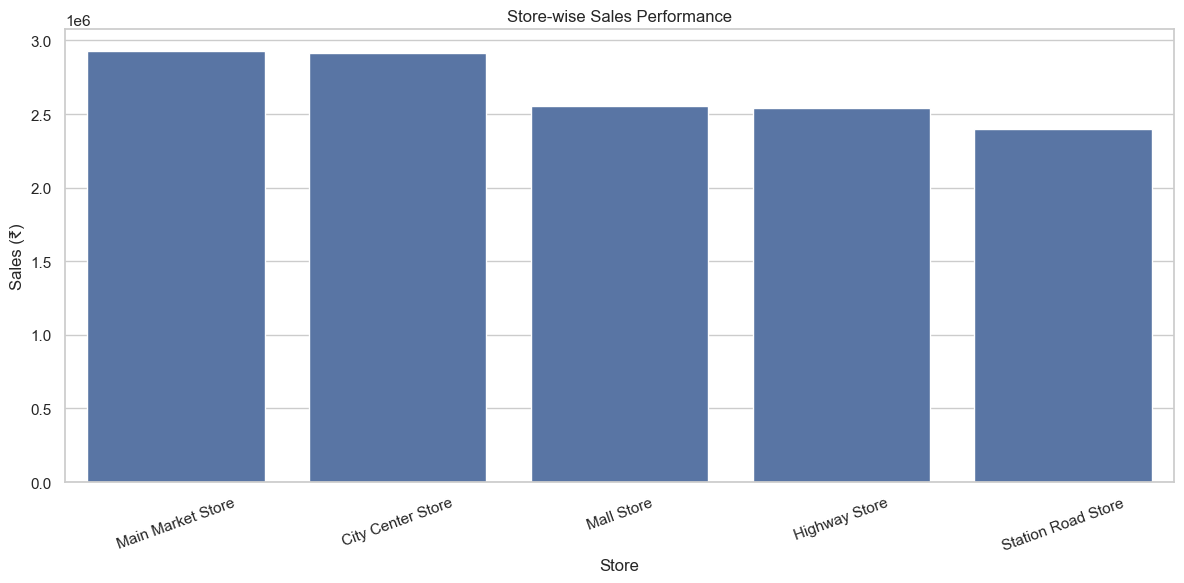

In [136]:
# Store Sales Chart 
plt.figure(figsize=(12, 6)) 
sns.barplot( data=store_performance,x="Store Name",y="Sales")
plt.title("Store-wise Sales Performance") 
plt.xlabel("Store") 
plt.ylabel("Sales (₹)") 
plt.xticks(rotation=20) 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_store_sales.png", dpi=300 ) 
plt.show()

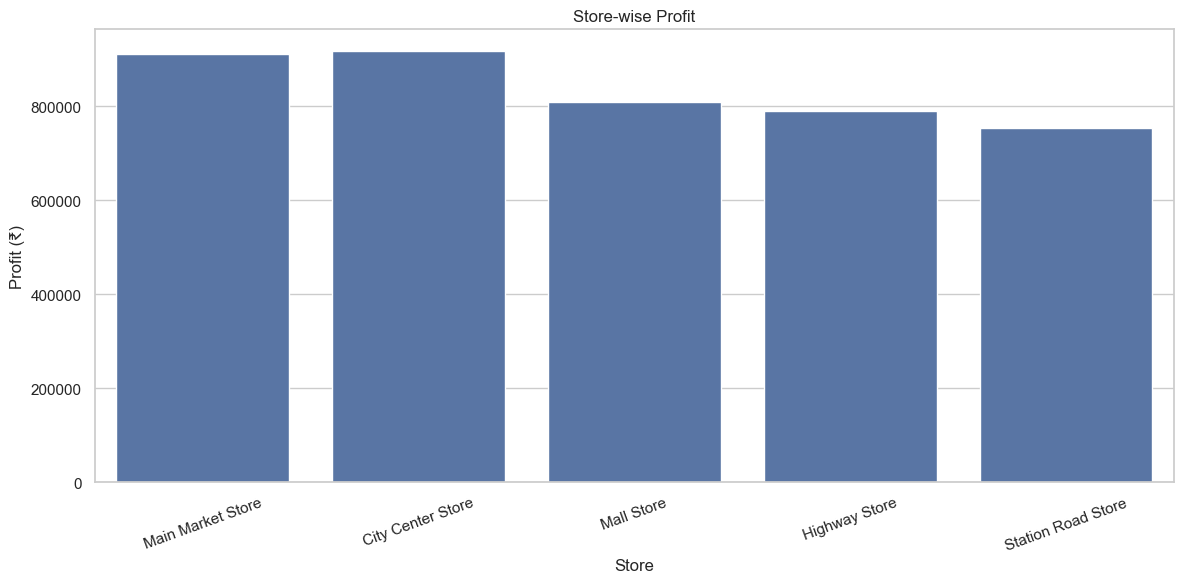

In [135]:
# Store Profit Chart 
plt.figure(figsize=(12, 6)) 
sns.barplot( data=store_performance, x="Store Name", y="Profit" ) 
plt.title("Store-wise Profit") 
plt.xlabel("Store") 
plt.ylabel("Profit (₹)") 
plt.xticks(rotation=20) 
plt.tight_layout() 
plt.savefig(f"{OUTPUT_DIR}/02_store_profit.png", dpi=300 ) 
plt.show()

## MODULE 2 — PRODUCT ANALYTICS

In [37]:
product_analysis = ( df.groupby( ["Product ID", "Product Name", "Product Category"] ).agg(Quantity_Sold=("Quantity", "sum"), 
       Sales=("Total Amount", "sum"), 
       Profit=("Profit", "sum"), 
       Transactions=("Transaction ID", "nunique"), 
       Discount=("Discount Amount", "sum") ) .reset_index())
product_analysis["Profit Margin %"] = ( product_analysis["Profit"] / product_analysis["Sales"] * 100 )

# Top 10 products by sales 
top_products = product_analysis.sort_values( "Sales", ascending=False ).head(10)
print("\nTop 10 Products by Sales:") 
print(top_products.to_string(index=False))


Top 10 Products by Sales:
Product ID        Product Name Product Category  Quantity_Sold     Sales   Profit  Transactions  Discount  Profit Margin %
      P008            Sneakers         Clothing            644 1908800.0 588600.0           311  152000.0        30.836127
      P007              Jacket         Clothing            681 1779960.0 622260.0           304  126840.0        34.959213
      P003         Smart Watch      Electronics            507 1642900.0 476800.0           228  131600.0        29.021852
      P018       Mixer Grinder   Home & Kitchen            440 1141420.0 327420.0           203   90580.0        28.685322
      P002   Bluetooth Speaker      Electronics            543 1111220.0 323870.0           248   83380.0        29.145444
      P019        Cookware Set   Home & Kitchen            482 1071600.0 348600.0           225   85200.0        32.530795
      P006               Jeans         Clothing            643  951760.0 340910.0           296   77040.0       

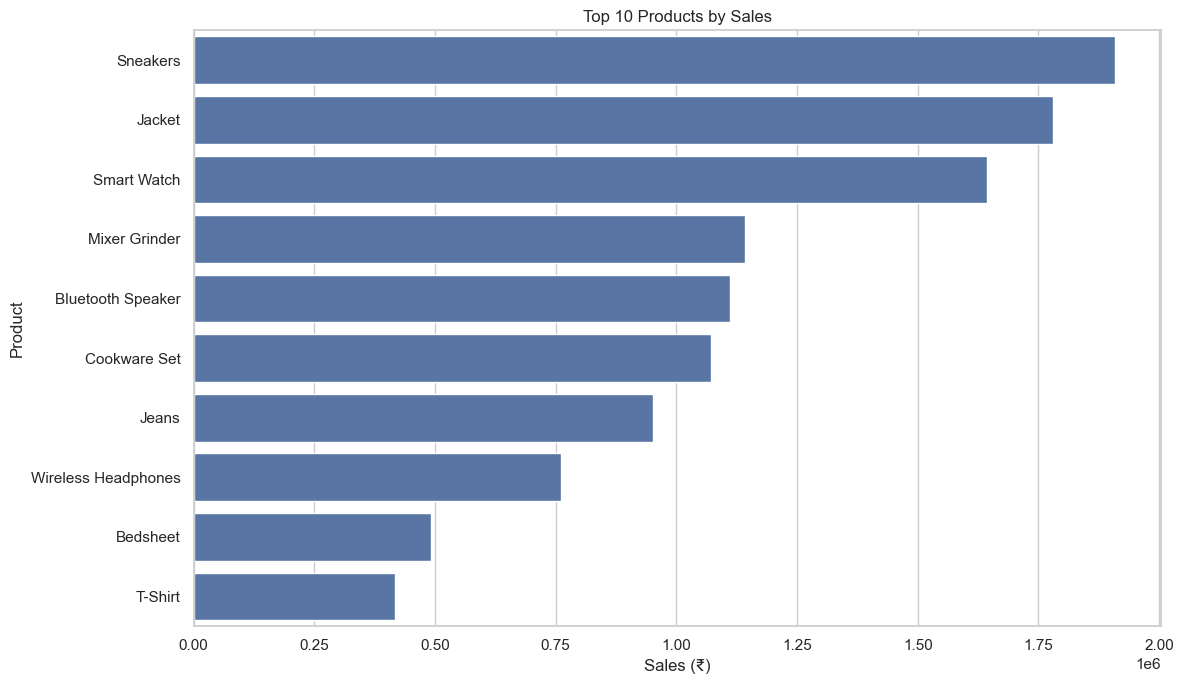

In [134]:
# Product Sales Chart 
plt.figure(figsize=(12, 7))
sns.barplot( data=top_products, x="Sales", y="Product Name" )
plt.title("Top 10 Products by Sales") 
plt.xlabel("Sales (₹)") 
plt.ylabel("Product") 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_top_products_sales.png", dpi=300 )
plt.show()

In [39]:
# Category Analysis 
category_analysis = ( df.groupby("Product Category") .agg( Sales=("Total Amount", "sum"), 
                                                          Profit=("Profit", "sum"), 
                                                          Quantity=("Quantity", "sum")) .reset_index())
category_analysis["Profit Margin %"] = ( category_analysis["Profit"] / category_analysis["Sales"] * 100 ) 
print("\nCategory Performance:") print(category_analysis.to_string(index=False))


Category Performance:
Product Category     Sales    Profit  Quantity  Profit Margin %
          Beauty  810396.0  267416.0      1830        32.998189
        Clothing 5056810.0 1721820.0      2616        34.049529
     Electronics 3725355.0 1110885.0      2010        29.819574
         Grocery  817292.5  150407.5      2534        18.403142
  Home & Kitchen 2919515.0  930895.0      1876        31.885262


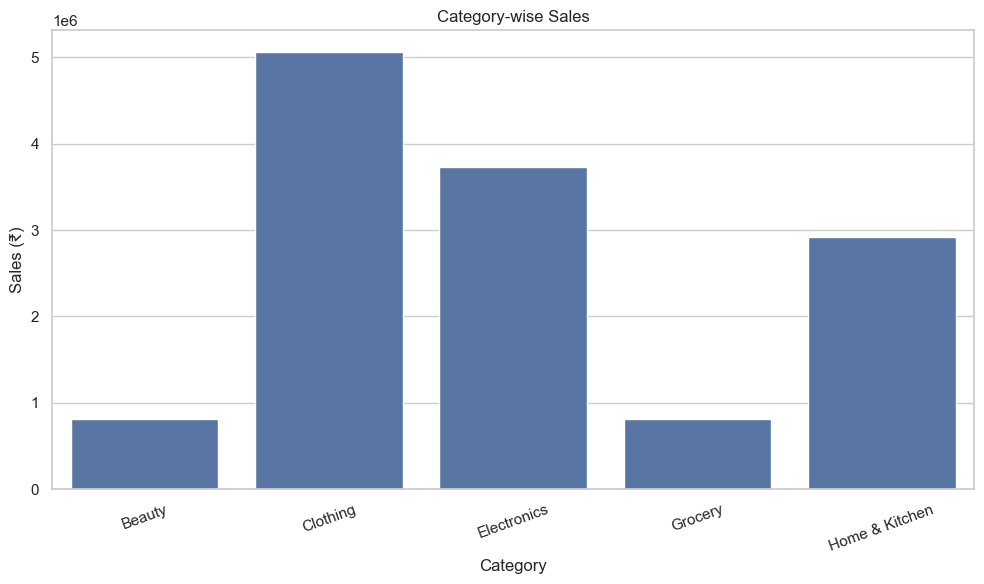

In [133]:
plt.figure(figsize=(10, 6)) 
sns.barplot( data=category_analysis, x="Product Category", y="Sales" )
plt.title("Category-wise Sales") 
plt.xlabel("Category") 
plt.ylabel("Sales (₹)") 
plt.xticks(rotation=20) 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04 category_sales.png", dpi=300)
plt.show()

## MODULE 3 — CUSTOMER ANALYTICS

In [48]:
customer_analysis = ( df.groupby("Customer ID") .agg( Total_Spending=("Total Amount", "sum"), 
                                                     Total_Quantity=("Quantity", "sum"), 
                                                     Transactions=("Transaction ID", "nunique"), 
                                                     Average_Order_Value=("Total Amount", "mean"), 
                                                     Profit_Generated=("Profit", "sum") ) .reset_index())

print("\nCustomer Analysis:")
print(customer_analysis.head(10))

# Gender analysis
gender_analysis = ( df.groupby("Gender") .agg( Sales=("Total Amount", "sum"), 
                                              Profit=("Profit", "sum"), 
                                              Customers=("Customer ID", "nunique"), 
                                              Quantity=("Quantity", "sum") ) .reset_index())

print("\nGender Analysis:")
print(gender_analysis.to_string(index=False))


Customer Analysis:
  Customer ID  Total_Spending  Total_Quantity  Transactions  \
0       C0001          7318.0              10             7   
1       C0002          3789.0               4             3   
2       C0003          7320.0               5             3   
3       C0004         13967.0               8             5   
4       C0005         31480.0              14             6   
5       C0006          2038.0               5             3   
6       C0007         10909.5              11             5   
7       C0008          5180.0               6             3   
8       C0009         11574.5              10             5   
9       C0010          6243.5               9             5   

   Average_Order_Value  Profit_Generated  
0          1045.428571            2443.0  
1          1263.000000            1439.0  
2          2440.000000            2390.0  
3          2793.400000            4897.0  
4          5246.666667           10310.0  
5           679.333333      

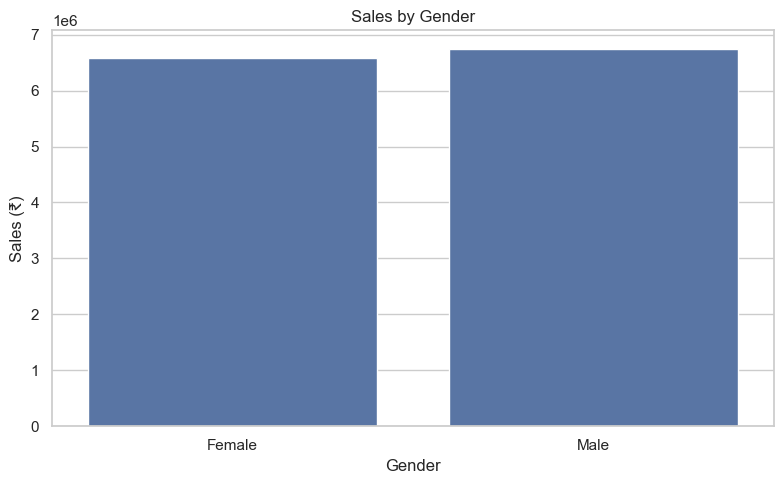

In [132]:
plt.figure(figsize=(8, 5)) 
sns.barplot( data=gender_analysis, x="Gender", y="Sales" ) 
plt.title("Sales by Gender") 
plt.xlabel("Gender") 
plt.ylabel("Sales (₹)") 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_gender_sales.png" , dpi=300)
plt.show()

In [50]:
# Age Group Analysis 
bins = [0, 18, 25, 35, 45, 55, 100] 
labels = [ "Under 18", "18-25", "26-35", "36-45", "46-55", "56+" ]
df["Age Group"] = pd.cut( df["Age"], bins=bins, labels=labels, include_lowest=True )
age_analysis = ( df.groupby("Age Group", observed=False) .agg( Sales=("Total Amount", "sum"), 
                                                              Customers=("Customer ID", "nunique"), 
                                                              Quantity=("Quantity", "sum") ) .reset_index())
print("\nAge Group Analysis:") 
print(age_analysis.to_string(index=False))


Age Group Analysis:
Age Group     Sales  Customers  Quantity
 Under 18 1032899.5         97       857
    18-25 2111838.5        182      1805
    26-35 4320133.0        401      3491
    36-45 3885794.0        325      3089
    46-55 1763576.0        157      1416
      56+  215127.5         23       208


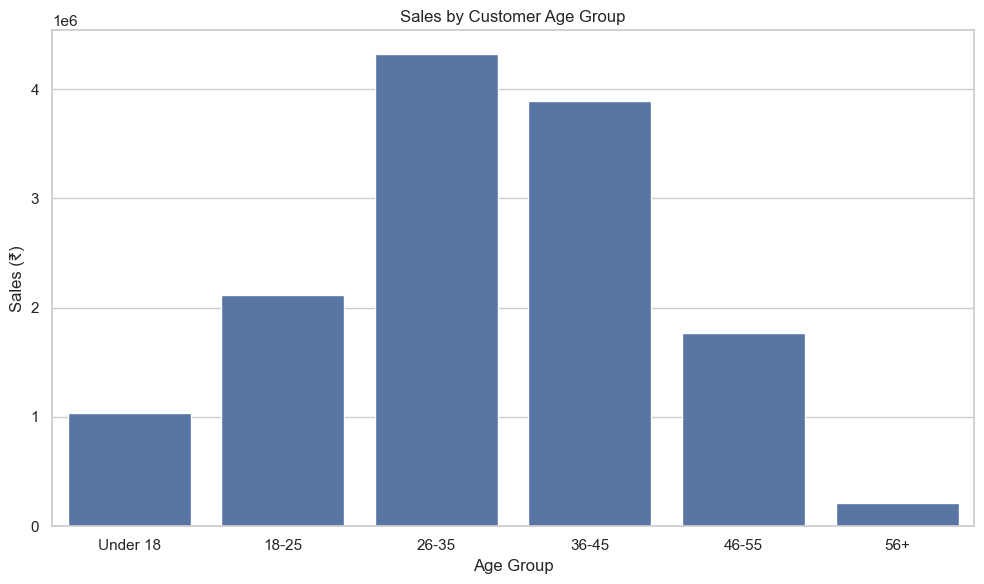

In [131]:
plt.figure(figsize=(10, 6)) 
sns.barplot( data=age_analysis, x="Age Group", y="Sales" )
plt.title("Sales by Customer Age Group") 
plt.xlabel("Age Group") 
plt.ylabel("Sales (₹)") 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_age_group_sales.png", dpi=300)
plt.show()

## MODULE 4 — INVENTORY ANALYTICS

In [53]:
inventory_analysis = ( df.groupby( ["Product ID", "Product Name", "Product Category"] ) .agg( Opening_Stock=("Opening Stock", "mean"), 
                                                                                             Purchased_Stock=("Purchased Stock", "sum"), 
                                                                                             Stock_Before_Sale=("Stock Before Sale", "mean"), 
                                                                                             Stock_After_Sale=("Stock After Sale", "mean"), 
                                                                                             Reorder_Level=("Reorder Level", "mean"), 
                                                                                             Quantity_Sold=("Quantity", "sum") ) .reset_index())
# Current stock estimate 
inventory_analysis["Stock Gap"] = ( inventory_analysis["Stock_After_Sale"] - inventory_analysis["Reorder_Level"] ) 
print("\nInventory Analysis:") 
print(inventory_analysis.head(10).to_string(index=False))

# Stock Status 
stock_status = ( df["Stock Status"] .value_counts() .reset_index())
stock_status.columns = [ "Stock Status", "Count" ]

print("\nStock Status:") 
print(stock_status.to_string(index=False))


Inventory Analysis:
Product ID        Product Name Product Category  Opening_Stock  Purchased_Stock  Stock_Before_Sale  Stock_After_Sale  Reorder_Level  Quantity_Sold  Stock Gap
      P001 Wireless Headphones      Electronics     169.521531            16046         246.296651        244.100478      41.511962            459 202.588517
      P002   Bluetooth Speaker      Electronics     173.479839            19450         251.907258        249.717742      39.955645            543 209.762097
      P003         Smart Watch      Electronics     166.973684            18365         247.521930        245.298246      39.438596            507 205.859649
      P004           USB Cable      Electronics     172.632743            18901         256.265487        254.048673      40.030973            501 214.017699
      P005             T-Shirt         Clothing     166.538206            24374         247.514950        245.362126      39.096346            648 206.265781
      P006               Jeans 

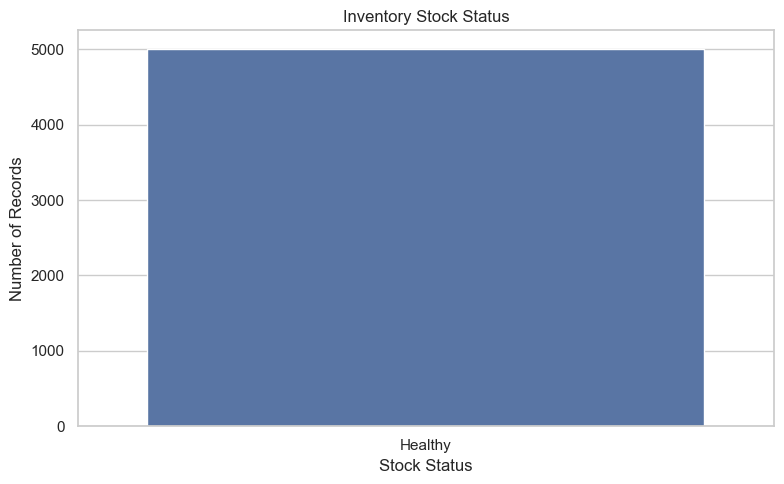

In [130]:
plt.figure(figsize=(8, 5)) 
sns.barplot( data=stock_status, x="Stock Status", y="Count" ) 
plt.title("Inventory Stock Status") 
plt.xlabel("Stock Status") 
plt.ylabel("Number of Records") 
plt.tight_layout() 
plt.savefig(f"{OUTPUT_DIR}/07_stock_status.png", dpi=300 ) 
plt.show()

In [55]:
# Low stock products 
low_stock = inventory_analysis[ inventory_analysis["Stock_After_Sale"] <= inventory_analysis["Reorder_Level"]]
print("\nProducts Requiring Reorder:") 
print(low_stock.to_string(index=False))


Products Requiring Reorder:
Empty DataFrame
Columns: [Product ID, Product Name, Product Category, Opening_Stock, Purchased_Stock, Stock_Before_Sale, Stock_After_Sale, Reorder_Level, Quantity_Sold, Stock Gap]
Index: []


## MODULE 5 — DISCOUNT ANALYSIS

In [60]:
discount_analysis = ( df.groupby("Discount %") .agg( Transactions=("Transaction ID", "nunique"), 
                                                    Gross_Sales=("Gross Sales", "sum"), 
                                                    Discount_Amount=("Discount Amount", "sum"), 
                                                    Net_Sales=("Total Amount", "sum"), 
                                                    Profit=("Profit", "sum") ) .reset_index())

discount_analysis["Profit Margin %"] = ( discount_analysis["Profit"] / discount_analysis["Net_Sales"] * 100 )
print("\nDiscount Analysis:") 
print(discount_analysis.to_string(index=False))


Discount Analysis:
 Discount %  Transactions  Gross_Sales  Discount_Amount  Net_Sales    Profit  Profit Margin %
          0          1532    4615070.0              0.0  4615070.0 1679170.0        36.384497
          5          1265    3675880.0         183794.0  3492086.0 1160111.0        33.221146
         10          1007    2836860.0         283686.0  2553174.0  749869.0        29.370070
         15           606    1697530.0         254629.5  1442900.5  366050.5        25.369074
         20           365     990310.0         198062.0   792248.0  161963.0        20.443472
         25           225     578520.0         144630.0   433890.0   64260.0        14.810205


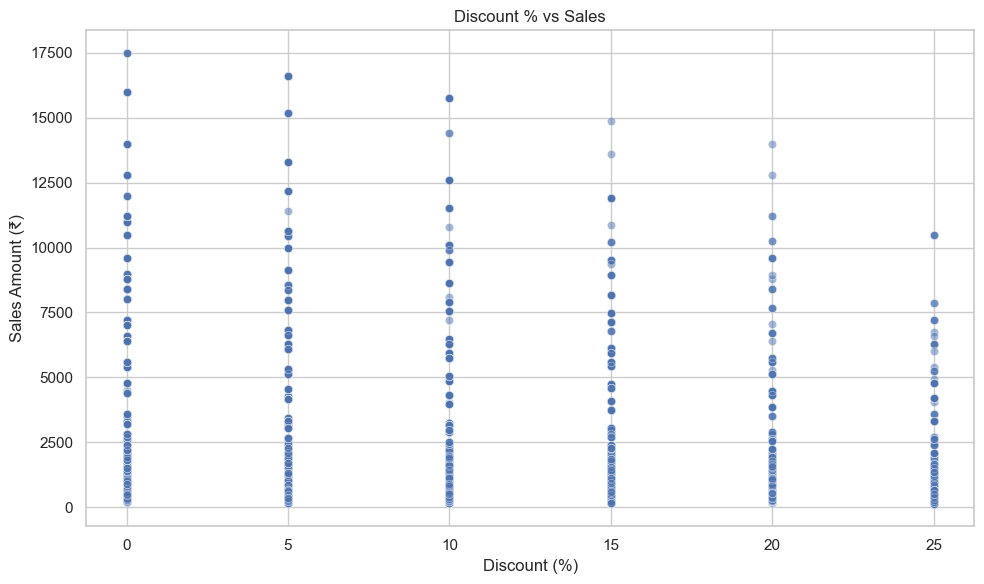

In [129]:
# Discount vs Sales 
plt.figure(figsize=(10, 6)) 
sns.scatterplot( data=df, x="Discount %", y="Total Amount", alpha=0.5 ) 
plt.title("Discount % vs Sales") 
plt.xlabel("Discount (%)") 
plt.ylabel("Sales Amount (₹)")
plt.tight_layout() 
plt.savefig(f"{OUTPUT_DIR}/08_discount_vs_sales.png", dpi=300 ) 
plt.show()

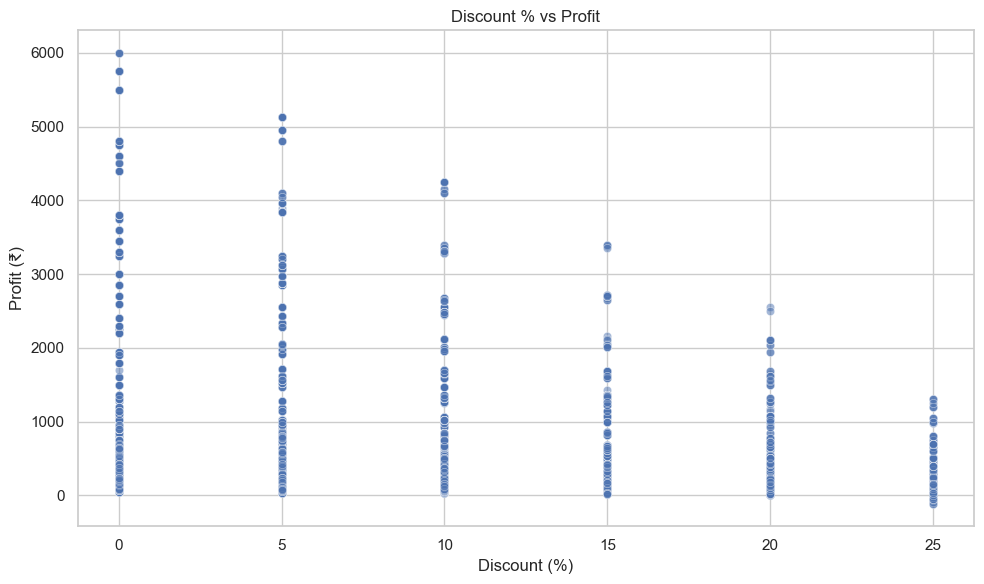

In [128]:
# Discount vs Profit 
plt.figure(figsize=(10, 6)) 
sns.scatterplot( data=df, x="Discount %", y="Profit", alpha=0.5 ) 
plt.title("Discount % vs Profit") 
plt.xlabel("Discount (%)") 
plt.ylabel("Profit (₹)") 
plt.tight_layout() 
plt.savefig(f"{OUTPUT_DIR}/09_discount_vs_profit.png", dpi=300 )
plt.show()

## MODULE 6 — SEASONAL SALES

In [65]:
seasonal_analysis = ( df.groupby("Season") .agg( Sales=("Total Amount", "sum"), 
                                                Profit=("Profit", "sum"), 
                                                Quantity=("Quantity", "sum"), 
                                                Transactions=("Transaction ID", "nunique") ) .reset_index() )

seasonal_analysis["Profit Margin %"] = ( seasonal_analysis["Profit"] / seasonal_analysis["Sales"] * 100 ) 
print("\nSeasonal Sales:") 
print(seasonal_analysis.to_string(index=False))


Seasonal Sales:
 Season     Sales    Profit  Quantity  Transactions  Profit Margin %
Monsoon 3437533.5 1088703.5      2790          1273        31.671066
 Spring 3401294.5 1071689.5      2752          1261        31.508283
 Summer 3257003.5 1015518.5      2687          1252        31.179534
 Winter 3233537.0 1005512.0      2637          1214        31.096351


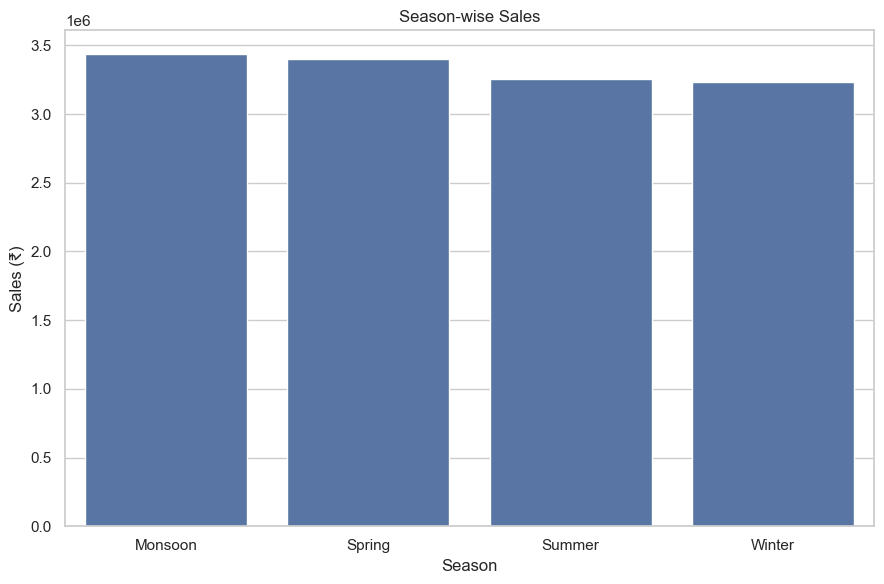

In [127]:
plt.figure(figsize=(9, 6)) 
sns.barplot( data=seasonal_analysis, x="Season", y="Sales" ) 
plt.title("Season-wise Sales") 
plt.xlabel("Season") 
plt.ylabel("Sales (₹)") 
plt.tight_layout() 
plt.savefig(f"{OUTPUT_DIR}/10_seasonal_sales.png", dpi=300) 
plt.show()

In [67]:
# Monthly Sales Trend 
monthly_sales = ( df.groupby(["Year", "Month", "Month Name"]) .agg( 
Sales=("Total Amount", "sum"), 
Profit=("Profit", "sum") ) .reset_index() .sort_values(["Year", "Month"]) ) 
print("\nMonthly Sales:") 
print(monthly_sales.to_string(index=False))


Monthly Sales:
 Year  Month Month Name    Sales   Profit
 2024      1    January 517309.0 159379.0
 2024      2   February 530480.5 168905.5
 2024      3      March 532330.0 169125.0
 2024      4      April 591050.0 186195.0
 2024      5        May 559181.5 171866.5
 2024      6       June 476267.5 147947.5
 2024      7       July 586903.5 183628.5
 2024      8     August 600841.5 190071.5
 2024      9  September 466274.5 147509.5
 2024     10    October 551799.0 181939.0
 2024     11   November 513964.0 154824.0
 2024     12   December 592932.5 187877.5
 2025      1    January 549153.5 172003.5
 2025      2   February 509179.0 153644.0
 2025      3      March 601419.0 189089.0
 2025      4      April 521740.0 166300.0
 2025      5        May 595574.0 189114.0
 2025      6       June 458954.0 138284.0
 2025      7       July 649524.0 205169.0
 2025      8     August 484513.0 150418.0
 2025      9  September 616143.0 189388.0
 2025     10    October 729257.5 232007.5
 2025     11   Nov

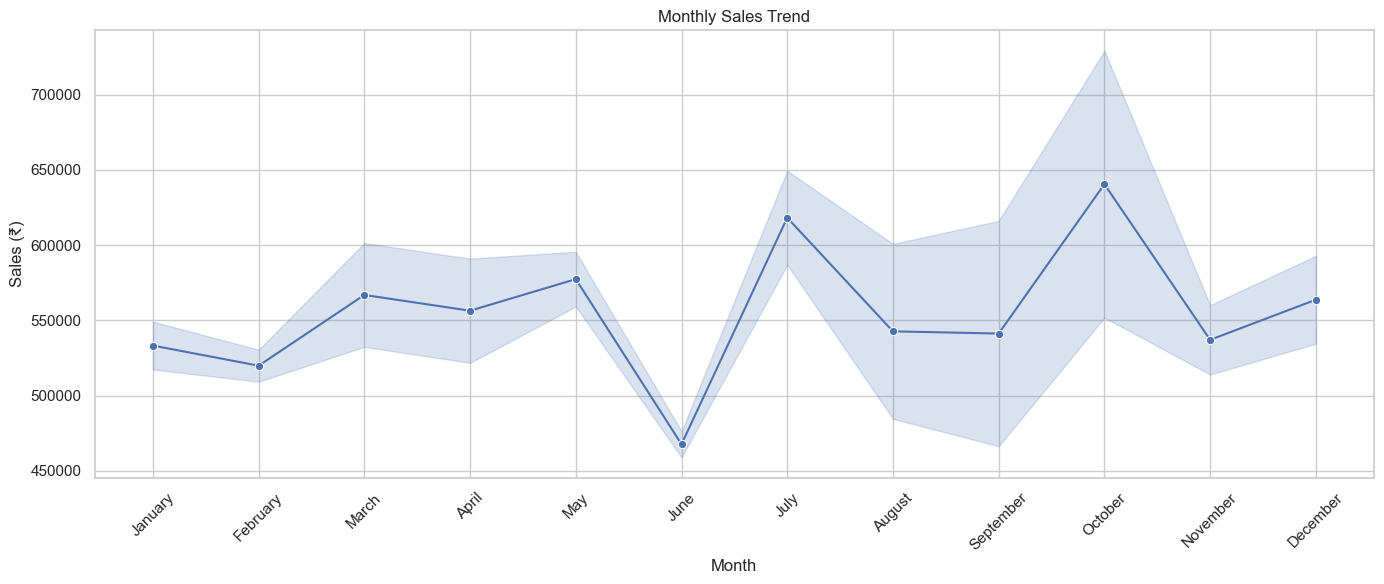

In [120]:
plt.figure(figsize=(14, 6)) 
sns.lineplot( data=monthly_sales, x="Month Name", y="Sales", marker="o" ) 
plt.title("Monthly Sales Trend") 
plt.xlabel("Month") 
plt.ylabel("Sales (₹)") 
plt.xticks(rotation=45) 
plt.tight_layout() 
plt.savefig(f"{OUTPUT_DIR}/11_monthly_sales.png", dpi=300 ) 
plt.show()

In [69]:
# Quarterly Sales 
quarterly_sales = ( df.groupby("Quarter") .agg( 
    Sales=("Total Amount", "sum"), 
    Profit=("Profit", "sum"), 
    Quantity=("Quantity", "sum") ) .reset_index() ) 
print("\nQuarterly Sales:") 
print(quarterly_sales.to_string(index=False))


Quarterly Sales:
Quarter     Sales    Profit  Quantity
     Q1 3239871.0 1012146.0      2663
     Q2 3202767.0  999707.0      2681
     Q3 3404199.5 1066184.5      2743
     Q4 3482531.0 1103386.0      2779


## MODULE 7 — PROFITABILITY

In [72]:
profitability = (df.groupby("Product Category") .agg( 
    Revenue=("Total Amount", "sum"), 
    Total_Cost=("Total Cost", "sum"), 
    Profit=("Profit", "sum"), 
    Quantity=("Quantity", "sum") ) .reset_index()) 

profitability["Profit Margin %"] = ( profitability["Profit"] / profitability["Revenue"] * 100 ) 
print("\nProfitability by Category:") 
print(profitability.to_string(index=False))


Profitability by Category:
Product Category   Revenue  Total_Cost    Profit  Quantity  Profit Margin %
          Beauty  810396.0    542980.0  267416.0      1830        32.998189
        Clothing 5056810.0   3334990.0 1721820.0      2616        34.049529
     Electronics 3725355.0   2614470.0 1110885.0      2010        29.819574
         Grocery  817292.5    666885.0  150407.5      2534        18.403142
  Home & Kitchen 2919515.0   1988620.0  930895.0      1876        31.885262


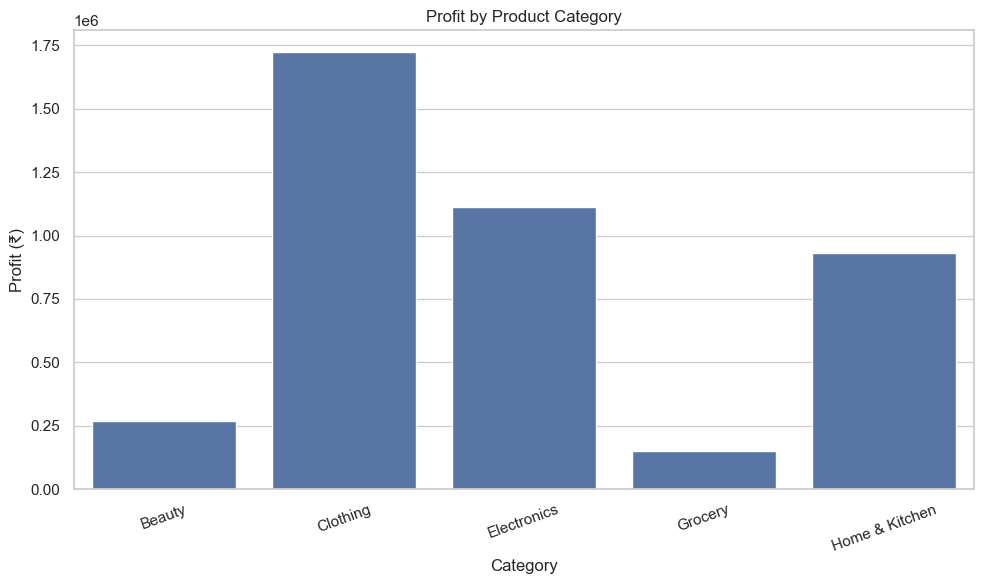

In [121]:
# Category Profit 
plt.figure(figsize=(10, 6)) 
sns.barplot( data=profitability, x="Product Category", y="Profit" ) 
plt.title("Profit by Product Category") 
plt.xlabel("Category") 
plt.ylabel("Profit (₹)")
plt.xticks(rotation=20)
plt.tight_layout() 
plt.savefig(f"{OUTPUT_DIR}/12_category_profit.png", dpi=300 ) 
plt.show()

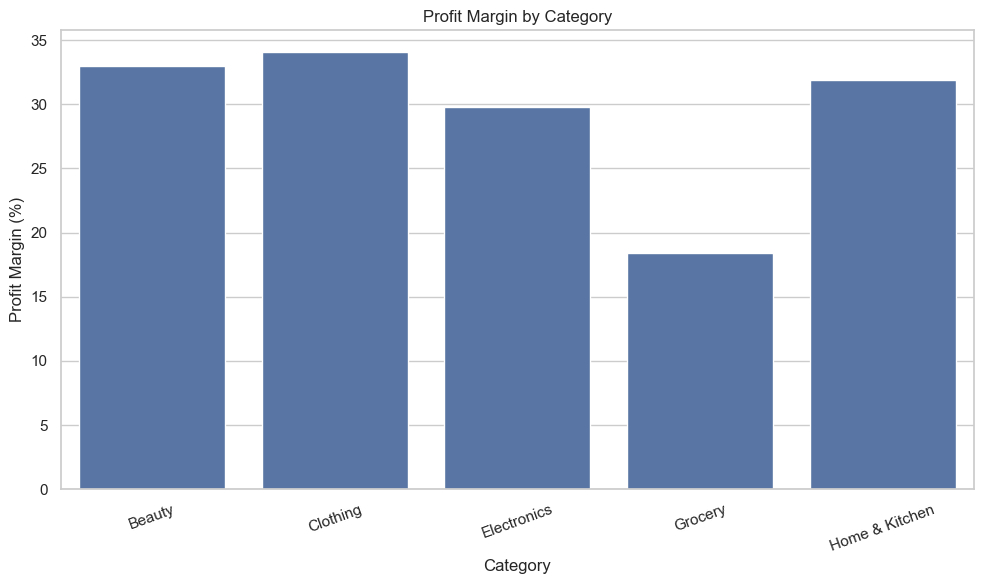

In [122]:
# Profit Margin 
plt.figure(figsize=(10, 6)) 
sns.barplot( data=profitability, x="Product Category", y="Profit Margin %" ) 
plt.title("Profit Margin by Category") 
plt.xlabel("Category") 
plt.ylabel("Profit Margin (%)") 
plt.xticks(rotation=20) 
plt.tight_layout() 
plt.savefig(f"{OUTPUT_DIR}/13_profit_margin.png", dpi=300 ) 
plt.show()

In [75]:
# Store profitability 
store_profitability = ( df.groupby(["Store ID", "Store Name"]) .agg( 
    Revenue=("Total Amount", "sum"), 
    Cost=("Total Cost", "sum"), 
    Profit=("Profit", "sum") ) .reset_index() )

store_profitability["Profit Margin %"] = ( store_profitability["Profit"] / store_profitability["Revenue"] * 100 ) 
print("\nStore Profitability:") 
print(store_profitability.to_string(index=False))


Store Profitability:
Store ID         Store Name   Revenue      Cost   Profit  Profit Margin %
   ST001  Main Market Store 2929125.0 2017980.0 911145.0        31.106388
   ST002  City Center Store 2911643.5 1994185.0 917458.5        31.509987
   ST003      Highway Store 2538493.0 1748575.0 789918.0        31.117596
   ST004         Mall Store 2553334.0 1744480.0 808854.0        31.678347
   ST005 Station Road Store 2396773.0 1642725.0 754048.0        31.460969


## MODULE 8 — STORE COMPARISON DASHBOARD

In [78]:
store_comparison = ( df.groupby(["Store ID", "Store Name", "City"]) .agg( 
    Sales=("Total Amount", "sum"), 
    Profit=("Profit", "sum"), 
    Cost=("Total Cost", "sum"), 
    uantity=("Quantity", "sum"), 
    Transactions=("Transaction ID", "nunique"), 
    Customers=("Customer ID", "nunique"), 
    Discount=("Discount Amount", "sum") ) .reset_index() ) 

store_comparison["Profit Margin %"] = ( store_comparison["Profit"] / store_comparison["Sales"] * 100 ) 
store_comparison["Average Order Value"] = ( store_comparison["Sales"] / store_comparison["Transactions"] ) 
print("\nStore Comparison:") 
print(store_comparison.to_string(index=False))


Store Comparison:
Store ID         Store Name         City     Sales   Profit      Cost  uantity  Transactions  Customers  Discount  Profit Margin %  Average Order Value
   ST001  Main Market Store     Pilibhit 2929125.0 911145.0 2017980.0     2414          1093        735  252375.0        31.106388          2679.894785
   ST002  City Center Store     Bareilly 2911643.5 917458.5 1994185.0     2300          1080        714  228966.5        31.509987          2695.966204
   ST003      Highway Store Shahjahanpur 2538493.0 789918.0 1748575.0     2083           967        674  212977.0        31.117596          2625.122027
   ST004         Mall Store         Agra 2553334.0 808854.0 1744480.0     2061           946        660  189096.0        31.678347          2699.084567
   ST005 Station Road Store      Lucknow 2396773.0 754048.0 1642725.0     2008           914        652  181387.0        31.460969          2622.289934


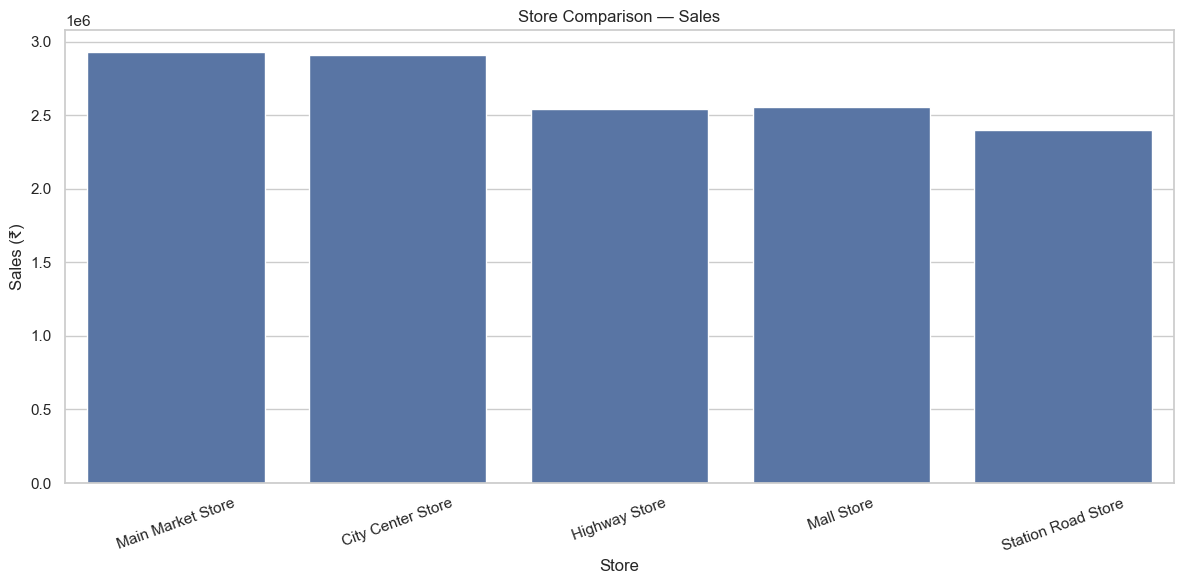

In [123]:
# Sales Comparison 
plt.figure(figsize=(12, 6)) 
sns.barplot( data=store_comparison, x="Store Name", y="Sales" ) 
plt.title("Store Comparison — Sales") 
plt.xlabel("Store") 
plt.ylabel("Sales (₹)") 
plt.xticks(rotation=20) 
plt.tight_layout() 
plt.savefig(f"{OUTPUT_DIR}/14_store_comparison_sales.png", dpi=300 ) 
plt.show()

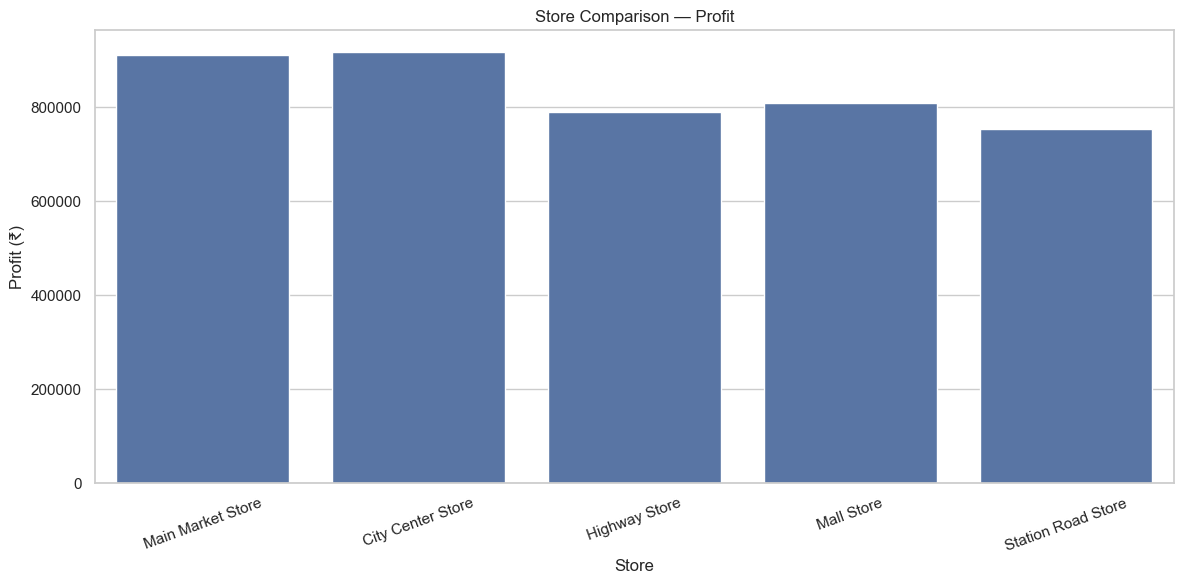

In [115]:
# Profit Comparison 
plt.figure(figsize=(12, 6)) 
sns.barplot( data=store_comparison, x="Store Name", y="Profit" ) 
plt.title("Store Comparison — Profit") 
plt.xlabel("Store")
plt.ylabel("Profit (₹)") 
plt.xticks(rotation=20)
plt.tight_layout() 
plt.savefig(f"{OUTPUT_DIR}/15_store_comparison_profit.png", dpi=100 ) 
plt.show()

## ADDITIONAL EDA

In [94]:
# Payment Method Analysis 
payment_analysis = ( df.groupby("Payment Method") .agg( 
    Transactions=("Transaction ID", "nunique"), 
    Sales=("Total Amount", "sum") ) .reset_index() ) 

print("\nPayment Method Analysis:") 
print(payment_analysis.to_string(index=False))


Payment Method Analysis:
Payment Method  Transactions     Sales
          Cash          1032 2832216.0
   Credit Card           907 2372313.0
    Debit Card           947 2523738.5
           UPI          2114 5601101.0


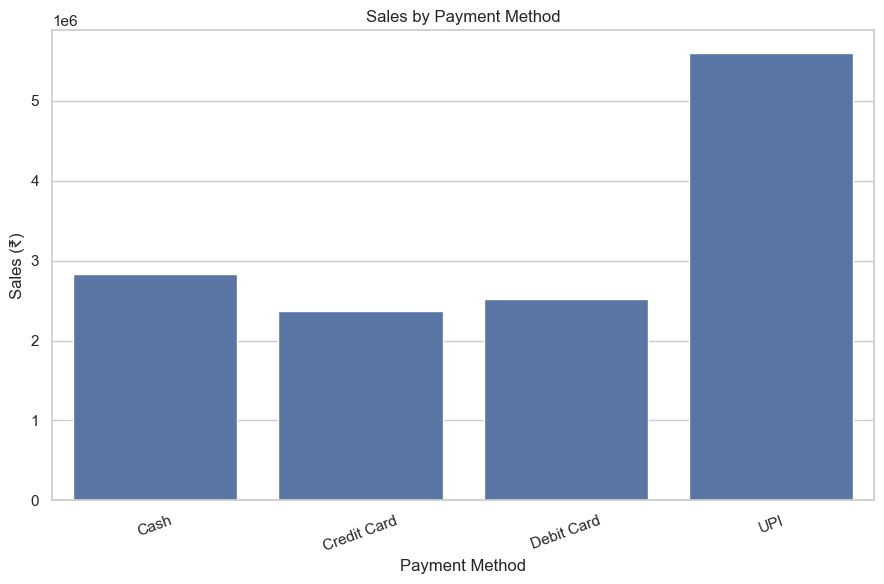

In [124]:
plt.figure(figsize=(9, 6))
sns.barplot(
    data=payment_analysis,
    x="Payment Method",
    y="Sales"
)
plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/16_payment_method.png", dpi=300 )
plt.show()

In [96]:
# Day-wise Sales 
day_analysis = ( df.groupby("Day Name") .agg(
    Sales=("Total Amount", "sum"),
    Profit=("Profit", "sum") ) .reset_index() )

print("\nDay-wise Sales:") 
print(day_analysis.to_string(index=False))


Day-wise Sales:
 Day Name     Sales   Profit
   Friday 1862863.5 570843.5
   Monday 1800962.5 570087.5
 Saturday 1900982.0 589262.0
   Sunday 1974861.0 622746.0
 Thursday 1995459.5 629199.5
  Tuesday 1980180.0 627815.0
Wednesday 1814060.0 571470.0


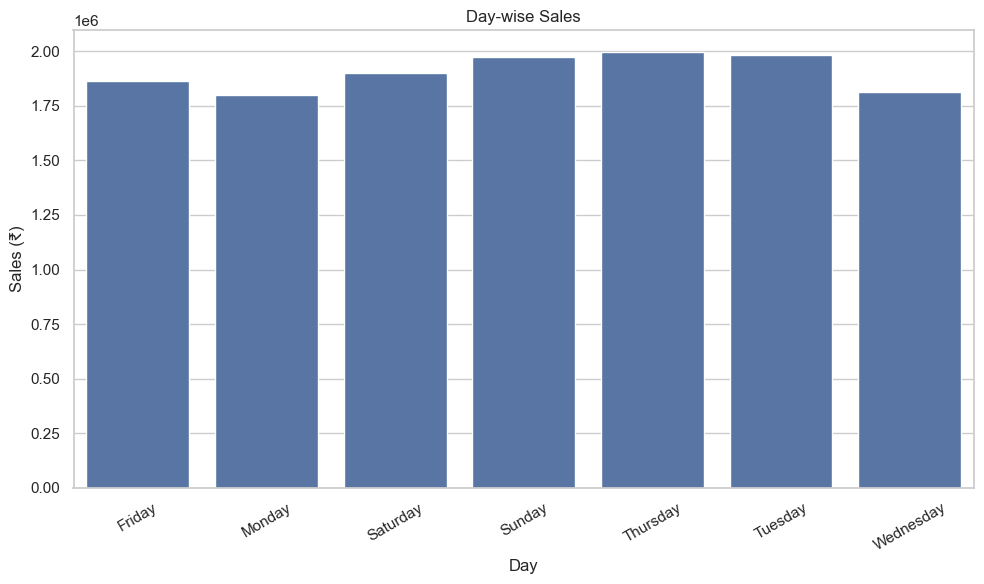

In [125]:
plt.figure(figsize=(10, 6)) 
sns.barplot( data=day_analysis, x="Day Name", y="Sales" )
plt.title("Day-wise Sales") 
plt.xlabel("Day") 
plt.ylabel("Sales (₹)") 
plt.xticks(rotation=30) 
plt.tight_layout() 
plt.savefig(f"{OUTPUT_DIR}/17_day_wise_sales.png", dpi=300 ) 
plt.show()

## CORRELATION ANALYSIS

In [99]:
numeric_columns = [ "Age", "Quantity", "Cost Price", "Price per Unit", "Discount %", "Gross Sales", "Discount Amount", "Total Amount", "Total Cost", "Profit", "Profit Margin %", "Opening Stock", "Purchased Stock", "Stock Before Sale", "Stock After Sale", "Reorder Level" ] 
correlation_matrix = df[numeric_columns].corr() 
print("\nCorrelation Matrix:") 
print(correlation_matrix.round(2))


Correlation Matrix:
                    Age  Quantity  Cost Price  Price per Unit  Discount %  \
Age                1.00      0.01        0.01            0.01       -0.01   
Quantity           0.01      1.00        0.00            0.00       -0.02   
Cost Price         0.01      0.00        1.00            1.00       -0.03   
Price per Unit     0.01      0.00        1.00            1.00       -0.03   
Discount %        -0.01     -0.02       -0.03           -0.03        1.00   
Gross Sales        0.01      0.51        0.75            0.76       -0.04   
Discount Amount    0.00      0.29        0.46            0.46        0.53   
Total Amount       0.01      0.50        0.75            0.75       -0.10   
Total Cost         0.01      0.50        0.76            0.76       -0.04   
Profit             0.01      0.49        0.69            0.70       -0.24   
Profit Margin %    0.01      0.03        0.04            0.08       -0.60   
Opening Stock      0.01      0.01       -0.01          

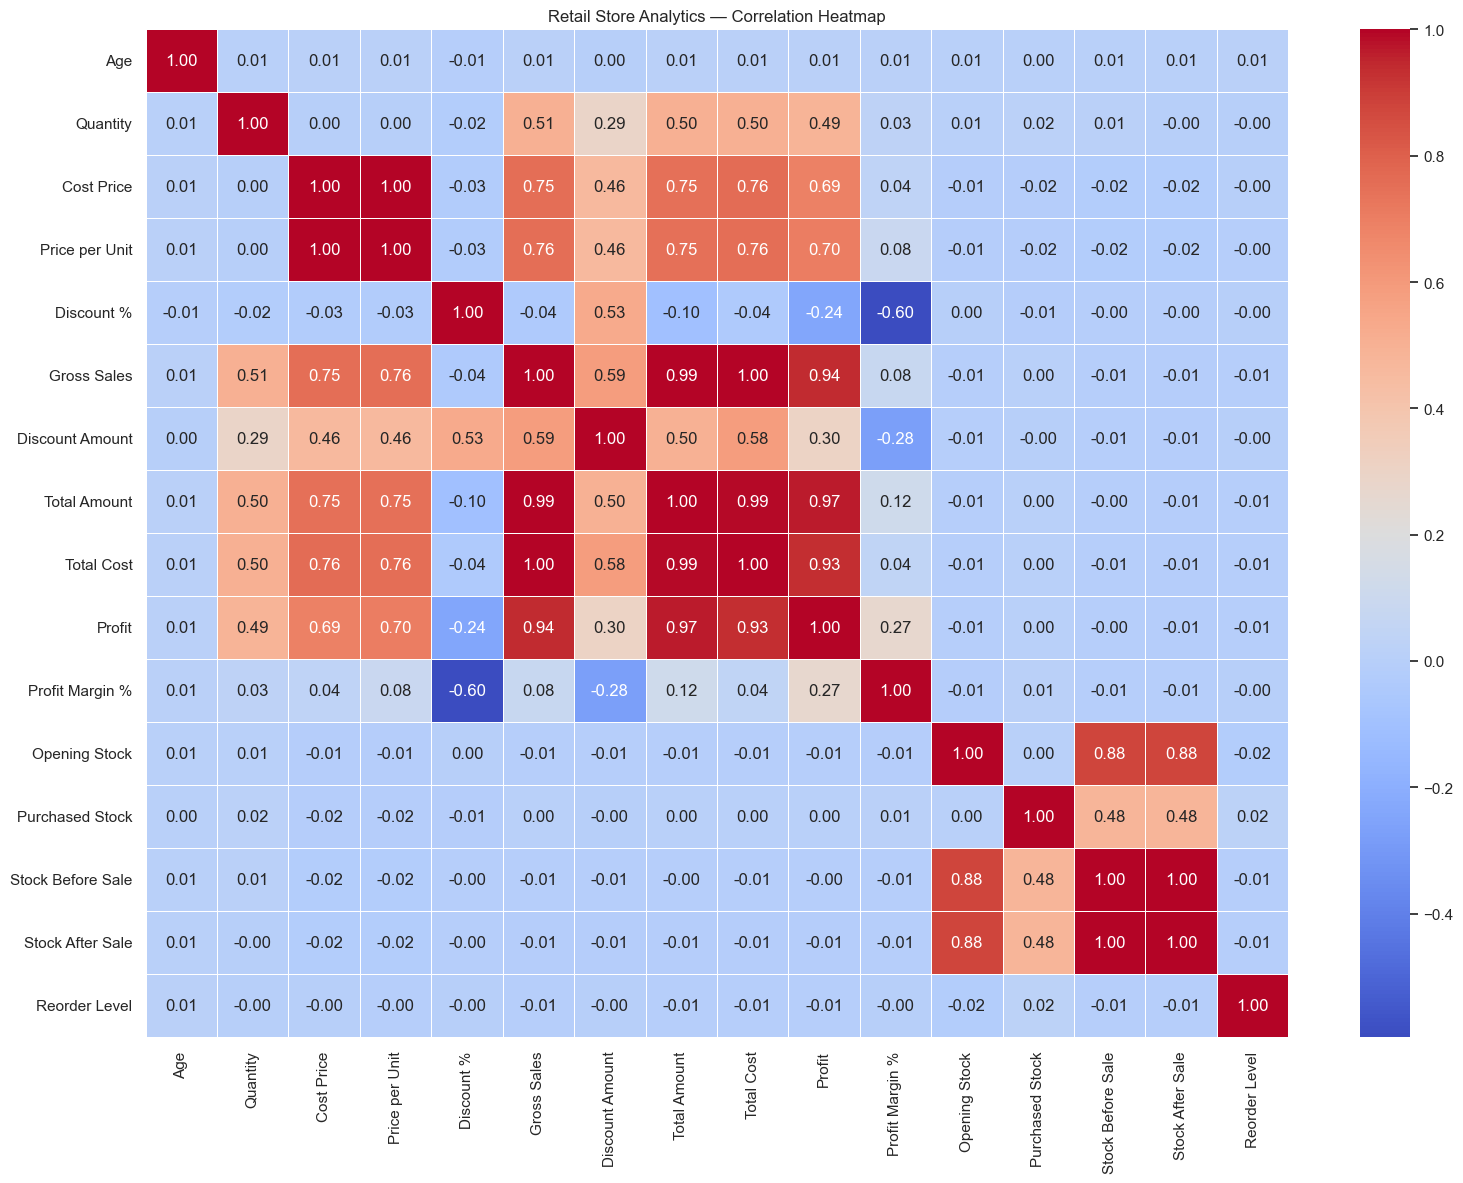

In [112]:
plt.figure(figsize=(16, 12)) 
sns.heatmap( correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5 ) 
plt.title("Retail Store Analytics — Correlation Heatmap") 
plt.tight_layout() 
plt.savefig( f"{OUTPUT_DIR}/18_correlation_heatmap.png", dpi=300)
plt.show()

## TOP / BOTTOM PERFORMERS

In [101]:
print("\nTop 10 Products by Revenue:")
print(
    product_analysis
    .sort_values("Sales", ascending=False)
    [["Product Name", "Product Category", "Sales", "Profit"]]
    .head(10)
    .to_string(index=False)
)

print("\nBottom 10 Products by Revenue:")
print(
    product_analysis
    .sort_values("Sales", ascending=True)
    [["Product Name", "Product Category", "Sales", "Profit"]]
    .head(10)
    .to_string(index=False)
)

print("\nTop Stores by Revenue:")
print(
    store_comparison
    .sort_values("Sales", ascending=False)
    [["Store Name", "City", "Sales", "Profit", "Profit Margin %"]]
    .to_string(index=False)
)


Top 10 Products by Revenue:
       Product Name Product Category     Sales   Profit
           Sneakers         Clothing 1908800.0 588600.0
             Jacket         Clothing 1779960.0 622260.0
        Smart Watch      Electronics 1642900.0 476800.0
      Mixer Grinder   Home & Kitchen 1141420.0 327420.0
  Bluetooth Speaker      Electronics 1111220.0 323870.0
       Cookware Set   Home & Kitchen 1071600.0 348600.0
              Jeans         Clothing  951760.0 340910.0
Wireless Headphones      Electronics  762030.0 211230.0
           Bedsheet   Home & Kitchen  492745.0 176845.0
            T-Shirt         Clothing  416290.0 170050.0

Bottom 10 Products by Revenue:
   Product Name Product Category    Sales   Profit
    Cooking Oil          Grocery 109143.0  20178.0
      Face Wash           Beauty 113587.5  39637.5
    Body Lotion           Beauty 135292.5  44562.5
       Tea 500g          Grocery 151102.0  40522.0
        Shampoo           Beauty 172851.0  56631.0
Wheat Flour 5kg  

## EXPORT ANALYTICS TO EXCEL

In [110]:
print("\n" + "=" * 30)
print("EXPORTING REPORT")
print("=" * 30)

excel_file = f"{OUTPUT_DIR}/Retail_Store_Analytics_Report.xlsx"

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:

    df.to_excel(
        writer,
        sheet_name="Raw Data",
        index=False
    )

    store_performance.to_excel(
        writer,
        sheet_name="Store Performance",
        index=False
    )

    product_analysis.to_excel(
        writer,
        sheet_name="Product Analytics",
        index=False
    )

    customer_analysis.to_excel(
        writer,
        sheet_name="Customer Analytics",
        index=False
    )

    inventory_analysis.to_excel(
        writer,
        sheet_name="Inventory",
        index=False
    )

    discount_analysis.to_excel(
        writer,
        sheet_name="Discount Analysis",
        index=False
    )

    seasonal_analysis.to_excel(
        writer,
        sheet_name="Seasonal Sales",
        index=False
    )

    profitability.to_excel(
        writer,
        sheet_name="Profitability",
        index=False
    )

    store_comparison.to_excel(
        writer,
        sheet_name="Store Comparison",
        index=False
    )

    correlation_matrix.to_excel(
        writer,
        sheet_name="Correlation"
    )

print(f"\nExcel report created successfully:")
print(excel_file)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 30)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 30)

print(f"""
Total Sales          : ₹{total_sales:,.2f}
Total Profit         : ₹{total_profit:,.2f}
Total Transactions   : {total_transactions:,}
Total Customers      : {total_customers:,}
Total Products       : {total_products:,}
Total Stores         : {total_stores:,}
Total Quantity Sold  : {total_quantity:,}
Total Discount       : ₹{total_discount:,.2f}
Average Order Value  : ₹{average_order_value:,.2f}
Overall Profit Margin: {overall_profit_margin:.2f}%

All charts have been saved inside:
{OUTPUT_DIR}/

Excel report:
{excel_file}
""")

print("=" * 30)


EXPORTING REPORT

Excel report created successfully:
retail_analytics_outputs/Retail_Store_Analytics_Report.xlsx

PROJECT COMPLETED SUCCESSFULLY

Total Sales          : ₹13,329,368.50
Total Profit         : ₹4,181,423.50
Total Transactions   : 5,000
Total Customers      : 1,185
Total Products       : 20
Total Stores         : 5
Total Quantity Sold  : 10,866
Total Discount       : ₹1,064,801.50
Average Order Value  : ₹2,665.87
Overall Profit Margin: 31.37%

All charts have been saved inside:
retail_analytics_outputs/

Excel report:
retail_analytics_outputs/Retail_Store_Analytics_Report.xlsx

